# Example 9: Eulerian house $\to$ butterfly image bridge

This notebook is the 28x28 image-mass version of the terminal-conditioning recipe: train a positive surrogate for

$$v_\tau^h(s)=\mathbb E_s[g_h(S_\tau^h)]$$

from free Eulerian rollouts, then simulate the conditioned conservative edge-flux dynamics.  The helper module keeps the experiment self-contained by using synthetic house and butterfly silhouettes; replace those arrays with real images after the smoke test works.


In [11]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "examples" / "eulerian_image_bridge.py").exists():
            return path
    raise RuntimeError("Could not find repository root containing examples/eulerian_image_bridge.py")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.eulerian_image_bridge import (
    EulerianImageBridgeConfig,
    PositiveHeatPotentialCNN,
    make_synthetic_house_image,
    make_synthetic_butterfly_image,
    normalize_image_to_measure,
    natural_horizon,
    train_heat_potential_surrogate,
    simulate_conditioned_image_bridge,
)

rng = np.random.default_rng(9)
torch.manual_seed(9)


T = 9.812e-07


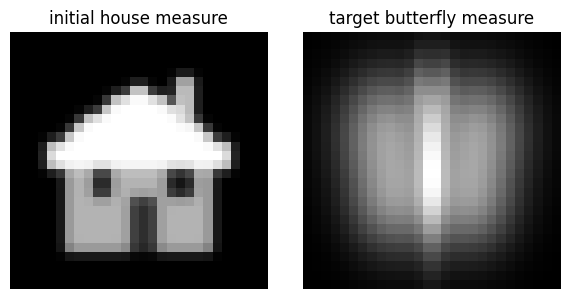

In [12]:
config = EulerianImageBridgeConfig(
    grid_size=28,
    alpha=32.0,
    horizon_scale=0.05,
    num_steps=4000,
    terminal_lambda=8.0,
    terminal_floor=1e-3,
    blur_sigmas=(2.0, 4.0),
    blur_weights=(0.5, 0.5),
)
T = natural_horizon(config)
print(f"T = {T:.3e}")

house_image = make_synthetic_house_image(config.grid_size)
butterfly_image = make_synthetic_butterfly_image(config.grid_size)
house = normalize_image_to_measure(house_image)
butterfly = normalize_image_to_measure(butterfly_image)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(house.reshape(config.grid_size, config.grid_size), cmap="gray")
axes[0].set_title("initial house measure")
axes[1].imshow(butterfly.reshape(config.grid_size, config.grid_size), cmap="gray")
axes[1].set_title("target butterfly measure")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


The next cell is intentionally modest.  For a real run, increase `num_batches` and `batch_size`; the smoke version verifies the pipeline quickly.

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PositiveHeatPotentialCNN(config, hidden_channels=64, hidden_dim=256)

history = train_heat_potential_surrogate(
    model,
    house,
    butterfly,
    num_batches=3000,        # increase to 1000+ for a serious run
    batch_size=128,         # increase to 128+ if memory allows
    rollout_steps_per_sample=1024,
    lr=3e-4,
    log_loss_weight=0.1,
    rng=rng,
    device=device,
)
print({k: v[-1] for k, v in history.items()})


KeyboardInterrupt: 

In [ ]:
result = simulate_conditioned_image_bridge(
    model,
    house,
    butterfly,
    config,
    rng=rng,
    num_steps=4000,       # use config.num_steps=4000 for the full recipe
    save_every=100,
    deterministic=True,
    device=device,
)
print(f"saved frames: {len(result.times)}")
print(f"clipping fraction: {result.clipping_fraction:.3f}")
print(f"terminal score: {result.terminal_scores[0]:.4f} -> {result.terminal_scores[-1]:.4f}")


saved frames: 41
clipping fraction: 0.680
terminal score: 0.3286 -> 0.0713


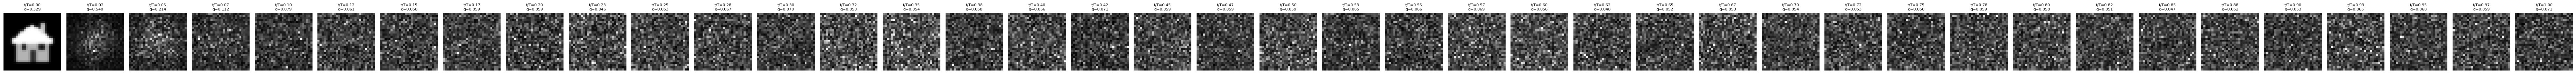

In [ ]:
num_frames = len(result.times)
fig, axes = plt.subplots(1, num_frames, figsize=(1.8 * num_frames, 2.2))
if num_frames == 1:
    axes = [axes]
for ax, t, state, score in zip(axes, result.times, result.trajectory, result.terminal_scores):
    ax.imshow(state.reshape(config.grid_size, config.grid_size), cmap="gray")
    ax.set_title(f"t/T={t / T:.2f}\ng={score:.3f}", fontsize=8)
    ax.axis("off")
plt.tight_layout()


## Next tuning steps

1. Calibrate `terminal_lambda` by free-rollout effective sample size.
2. Start with blurred terminal scales `(1.0, 2.0)` and add a sharp `0.0` term only after the bridge is stable.
3. Monitor the clipping fraction.  If it is high, increase `num_steps`, reduce `horizon_scale`, or lower the terminal sharpness.
4. Once the synthetic bridge works, replace `house_image` and `butterfly_image` with real 28x28 grayscale arrays and keep the same normalization.
